# Decision Tree (via metadata only)

## Imports

### Import data

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('../../data/model-ready.csv')
df.head()

,ISRC,Genre,Track,Album Name,Artist,All Time Rank,Track Score,Spotify Streams,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,AirPlay Spins,Pandora Streams,Pandora Track Stations,Shazam Counts,Explicit Track,Length,Releases,Registration Country,Followers,TikTok Views per Post,TikTok Impact,TikTok View-to-Like Ratio,TikTok Likes per Post,YouTube View-to-Like Ratio,Shazam Conversion Rate,Days Since Release,Label Prob,Label
0,QM24S2402528,Other,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,1,725.4,390470936,92,84274754,1713126,5767700,651565900,5332281936,40975,18004655,22931,2669262,0,155.1510,1,United States,847504.0,924.507505,0.000011,8.183795,112.968044,49.193524,0.000493,344,0.734589,1
1,USUG12400910,Rap,Not Like Us,Not Like Us,Kendrick Lamar,2,545.9,323703884,92,116347040,3486739,674700,35223547,208339025,40778,7780028,28444,1118279,1,274.1920,5,United States,38589324.0,308.787646,0.000003,5.914765,52.206158,33.368430,0.003444,336,0.721077,1
2,QZJ842400387,Other,i like the way you kiss me,I like the way you kiss me,Artemas,3,538.4,601309283,92,122599116,2228730,3025400,275154237,3369120610,74333,5022621,5639,5285340,0,143.1865,8,United States,1133424.0,1113.611625,0.000009,12.244480,90.948022,55.008485,0.001514,382,0.771418,1
3,USSM12209777,Other,Flowers,Flowers - Single,Miley Cyrus,4,444.9,2031280633,85,1096100899,10629796,7189811,1078757968,14603725994,1474799,190260277,203384,11822942,0,200.4530,30,United States,25620499.0,2031.169664,0.000002,13.537537,150.039802,103.115883,0.000753,814,0.799485,1
4,USAT22311371,Other,Lovin On Me,Lovin On Me,Jack Harlow,6,410.1,670665438,83,131148091,1392593,4202367,214943489,2938686633,522042,138529362,50982,4517131,1,138.4110,13,United States,4106706.0,699.293192,0.000005,13.671903,51.148183,94.175396,0.001471,512,0.758437,1


### Import modules

For Decision Tree, we use scikit-learn's DecisionTreeClassifier:
1. DecisionTreeClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

To interpret results, we use scikit-learn's ConfusionMatrixDisplay and tree.export_graphviz:
1. ConfusionMatrixDisplay: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
2. tree.export_graphviz: https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

## Data Prep

### Custom functions to reduce code repetition

See file at `./custom_data_prep.py` for the code.

In [2]:
from custom_data_prep import (
    my_corr_plotter
)

### Feature selection

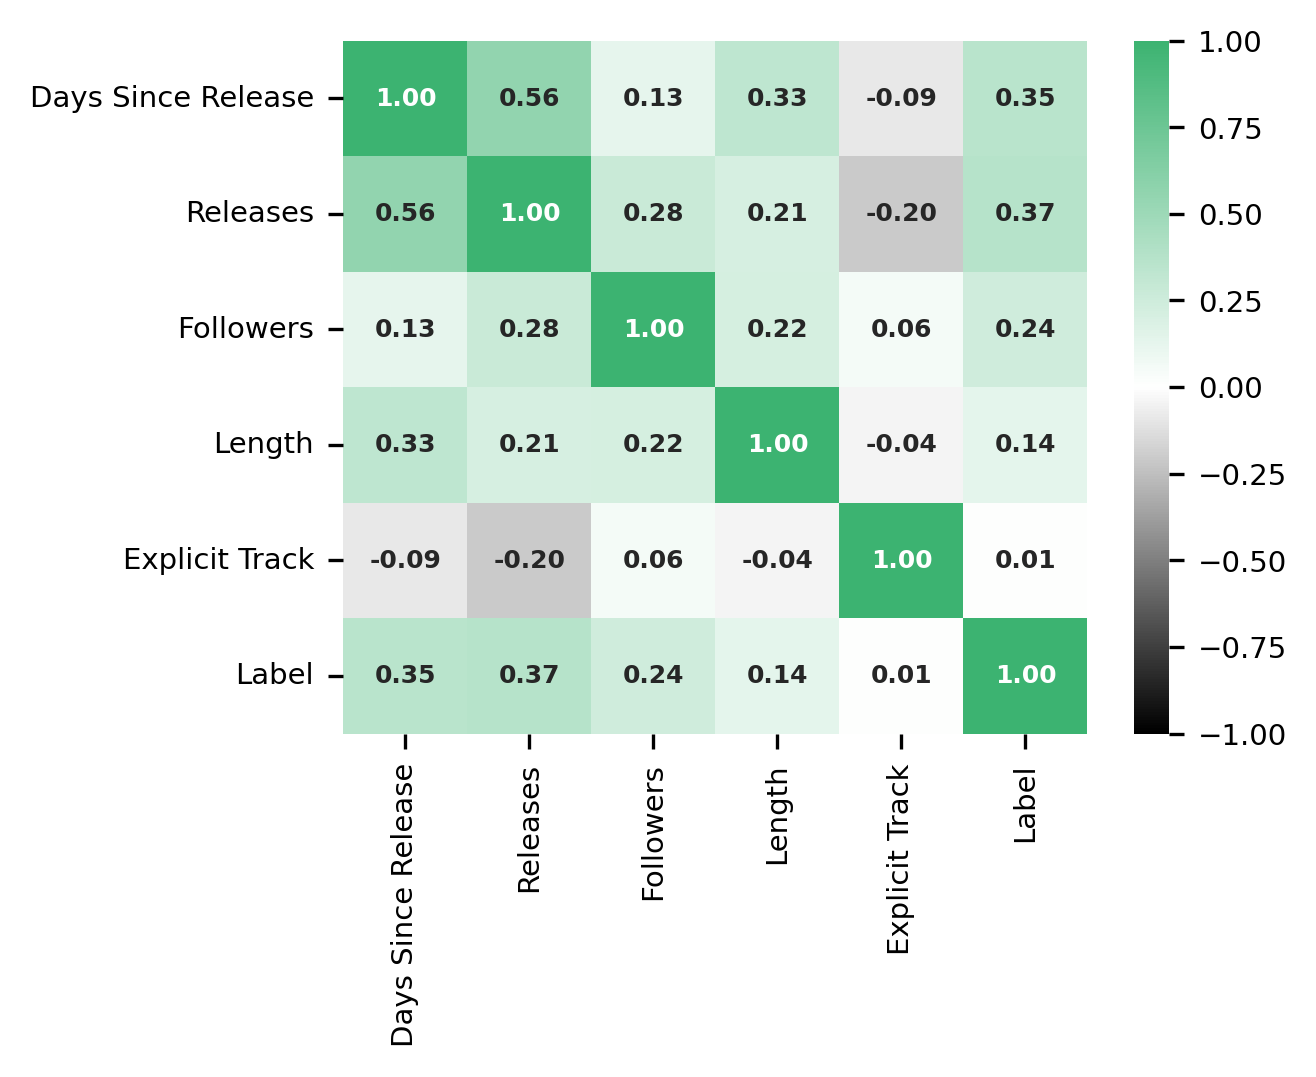

In [17]:
df_dt = df[[# Metadata
            'Genre',
            'Days Since Release',
            'Releases',
            'Followers',
            'Length',
            'Explicit Track',
    
            'Label']]
df_dt.head()

my_corr_plotter(df_dt, inner_fontsize=6, outer_fontsize=7)

### Encode categorical as one-hot

In [4]:
genre_encoded = pd.get_dummies(df_dt['Genre'], prefix='Genre')
df_dt = df_dt.drop('Genre', axis=1)
df_dt = pd.concat([df_dt, genre_encoded], axis=1)
df_dt.head()

,Days Since Release,Releases,Followers,Length,Explicit Track,Label,Genre_Country,Genre_Electronic,Genre_Latin,Genre_Other,Genre_Pop,Genre_R&B,Genre_Rap,Genre_Reggaeton,Genre_Rock
0,344,1,847504.0,155.1510,0,1,0,0,0,1,0,0,0,0,0
1,336,5,38589324.0,274.1920,1,1,0,0,0,0,0,0,1,0,0
2,382,8,1133424.0,143.1865,0,1,0,0,0,1,0,0,0,0,0
3,814,30,25620499.0,200.4530,0,1,0,0,0,1,0,0,0,0,0
4,512,13,4106706.0,138.4110,1,1,0,0,0,1,0,0,0,0,0


## Model Data

### Custom classes to reduce code repetition

See file at `./custom_model_prep.py` for the code.

In [5]:
from custom_model_prep import MySplitter, MyResults

### Decision Tree

In [6]:
%pip install graphviz --quiet

Note: you may need to restart the kernel to use updated packages.


Training Data: (2648 rows ~80.0%)



,Days Since Release,Releases,Followers,Length,Explicit Track,Label,Genre_Country,Genre_Electronic,Genre_Latin,Genre_Other,Genre_Pop,Genre_R&B,Genre_Rap,Genre_Reggaeton,Genre_Rock
507,558,2,91583244.0,165.000,1,1,0,0,0,0,0,0,0,1,0
1338,1472,5,55058075.0,203.506,0,1,0,0,0,0,0,0,0,1,0
2965,1674,1,27688395.0,202.008,1,1,0,0,0,0,0,1,0,0,0
1479,2486,39,9520807.0,195.680,0,1,0,0,0,1,0,0,0,0,0
839,632,22,8988048.0,156.391,1,1,0,0,0,1,0,0,0,0,0


Testing Data: (663 rows ~20.0%)



,Days Since Release,Releases,Followers,Length,Explicit Track,Label,Genre_Country,Genre_Electronic,Genre_Latin,Genre_Other,Genre_Pop,Genre_R&B,Genre_Rap,Genre_Reggaeton,Genre_Rock
1317,1065,2,91583244.0,198.000,1,0,0,0,0,0,0,0,0,1,0
441,694,1,23674002.0,215.600,0,1,0,0,1,0,0,0,0,0,0
568,2157,41,119292346.0,219.947,1,1,0,0,0,0,1,0,0,0,0
1639,1598,26,12414259.0,193.000,0,1,0,0,0,1,0,0,0,0,0
357,2249,2,12412675.0,166.560,1,1,0,0,0,1,0,0,0,0,0


Feature Names:
['Days Since Release' 'Releases' 'Followers' 'Length' 'Explicit Track'
 'Genre_Country' 'Genre_Electronic' 'Genre_Latin' 'Genre_Other'
 'Genre_Pop' 'Genre_R&B' 'Genre_Rap' 'Genre_Reggaeton' 'Genre_Rock']

Class Names:
['Low', 'High']


Accuracy: 0.7572
Precision: 0.7948
Recall:    0.8200
F1 Score:  0.8072


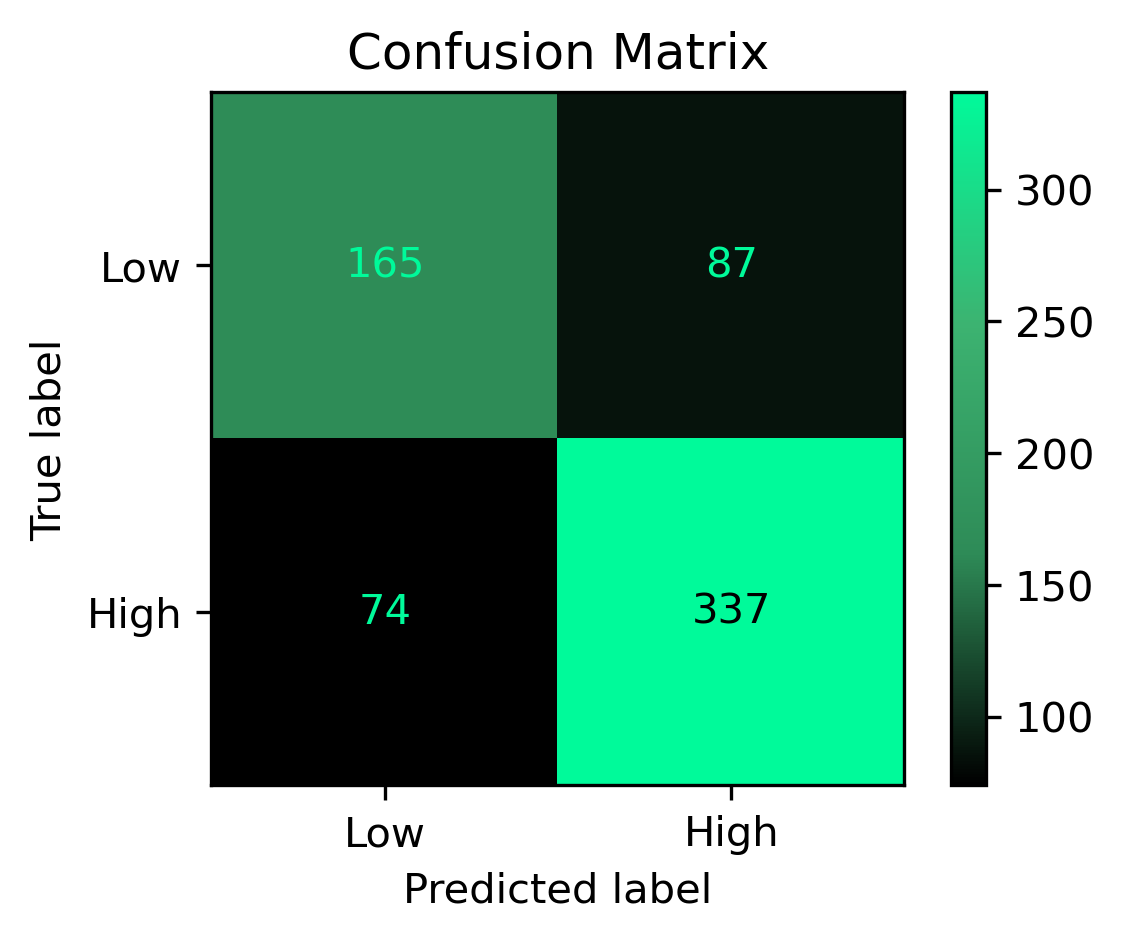

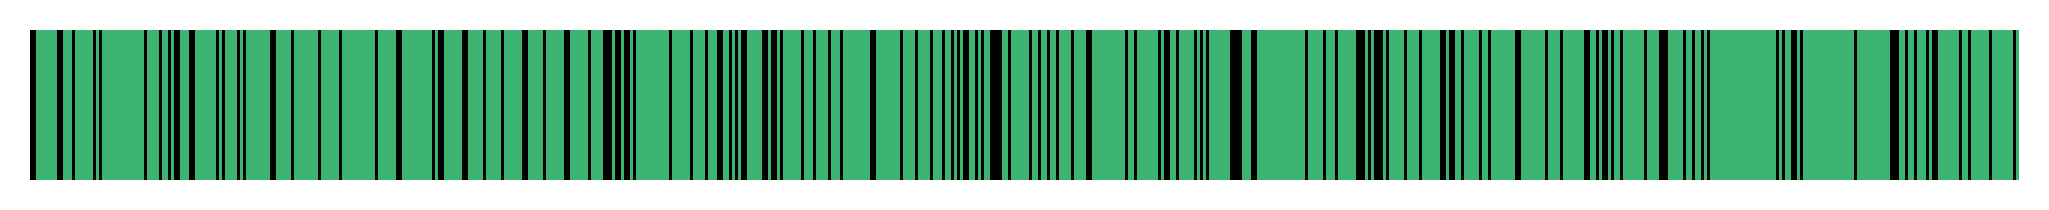

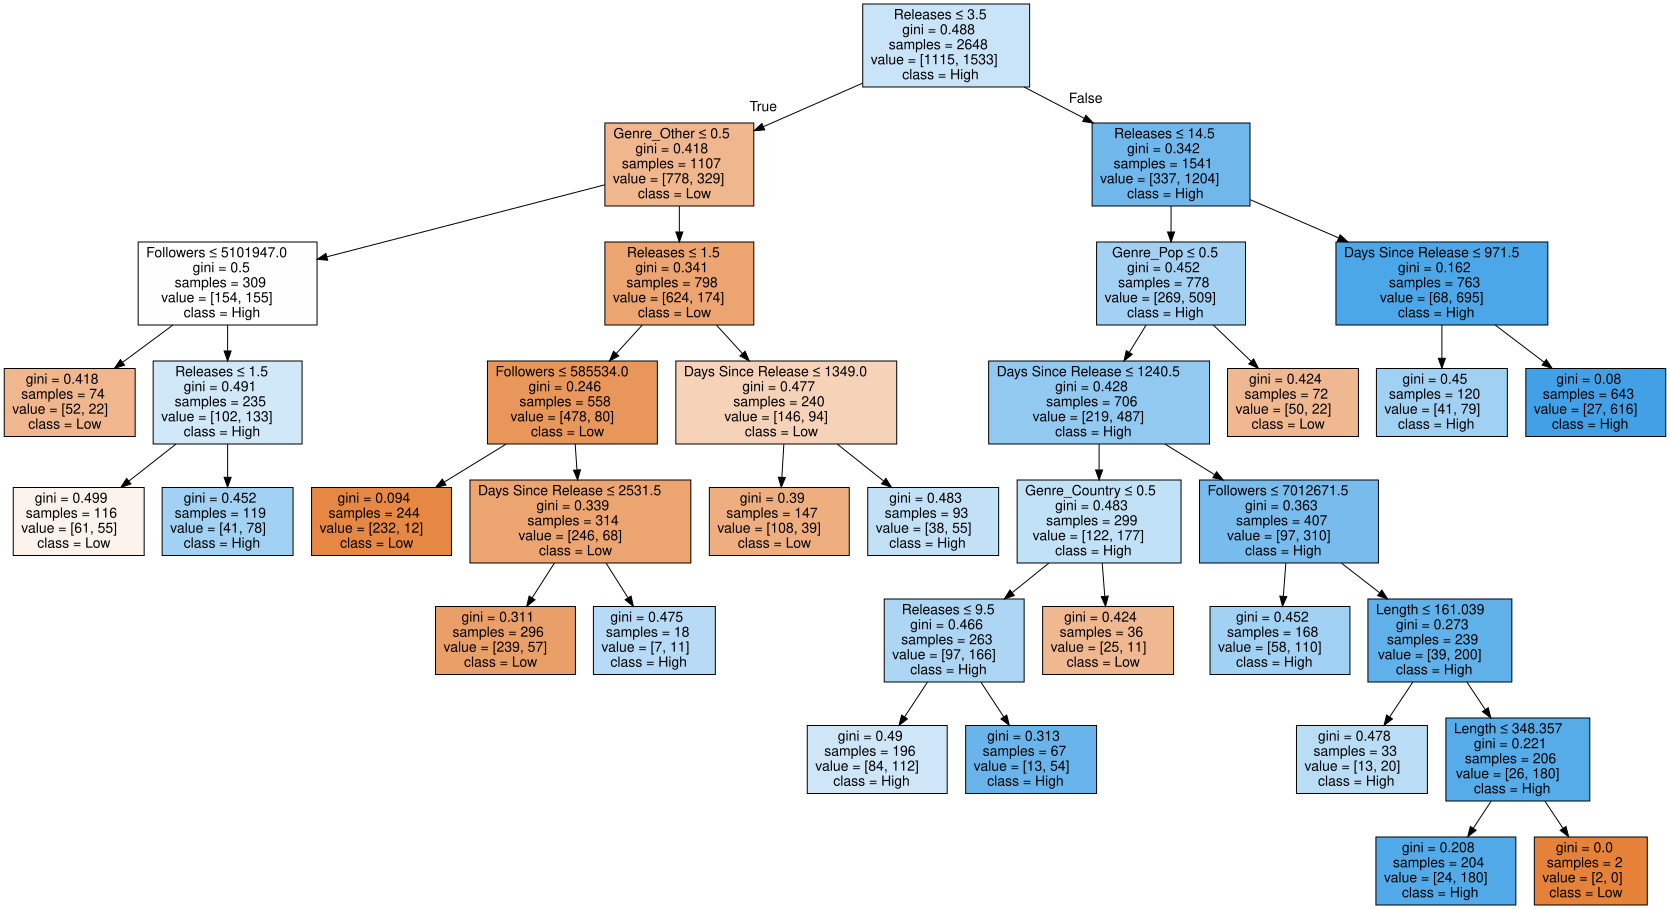

<Figure size 6000x3000 with 0 Axes>

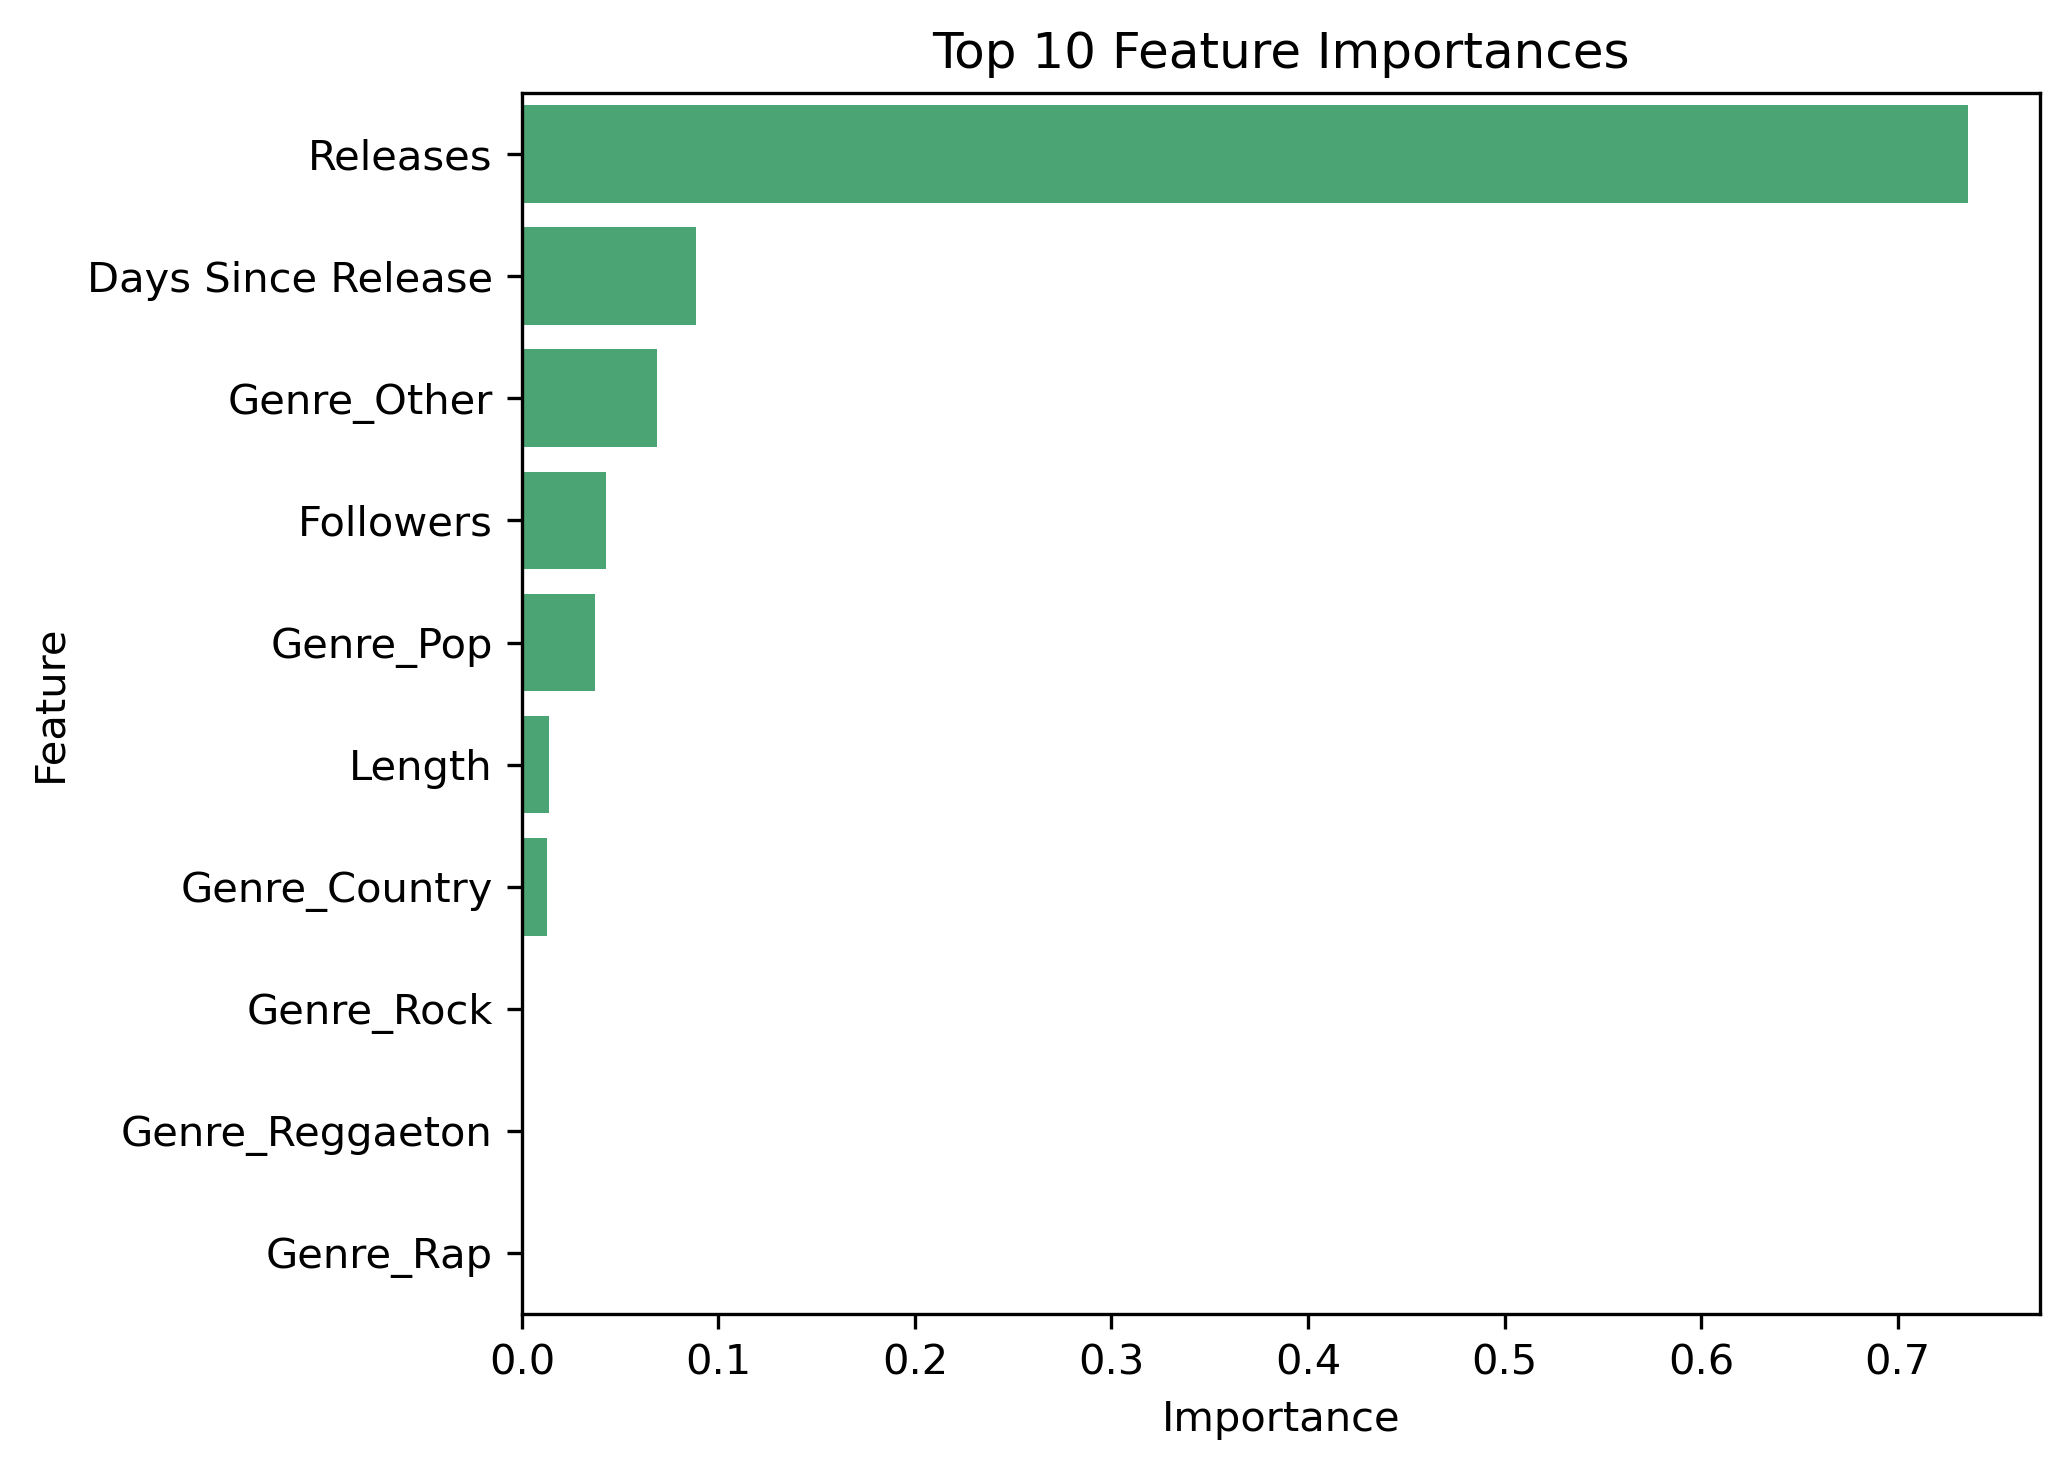

In [7]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
import graphviz
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

RSEED = 22
CCP_ALPHA = 0.001


# 2. Splitting
splitter = MySplitter(df_dt)

# -- Train-test split
train_df, test_df = splitter.train_test()
# -- X-y split
train_X, train_y, test_X, test_y, features, classes = splitter.x_y(train_df, test_df)


# 3. Normalization
# -- Decision Trees do not need normalization


# 4. Training
DT = DecisionTreeClassifier(random_state=RSEED, min_samples_split=205, ccp_alpha=CCP_ALPHA)
DT.fit(train_X, train_y)


# 5. Prediction
prediction = DT.predict(test_X)


# 6. Results
results = MyResults(test_y, prediction, classes)

# -- Via metrics
results.print_metrics()
# -- Via confusion matrix
results.plot_confusion_matrix()
# -- Via prediction barcode
results.plot_barcode()

# -- Via decision tree
plt.figure(figsize=(20, 10))
tree_visualization = tree.export_graphviz(DT, feature_names=features, class_names=classes, filled=True, special_characters=True)
graph = graphviz.Source(tree_visualization)

display(graph)

graph.render('dt-viz-metadata', format='pdf', cleanup=True)

# -- Via feature importance
plt.figure(figsize=(7, 5))
importances = DT.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10

sns.barplot(
    x=importances[indices[:top_n]],
    y=np.array(features)[indices[:top_n]],
    color='mediumseagreen'
)
plt.title(f'Top {top_n} Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

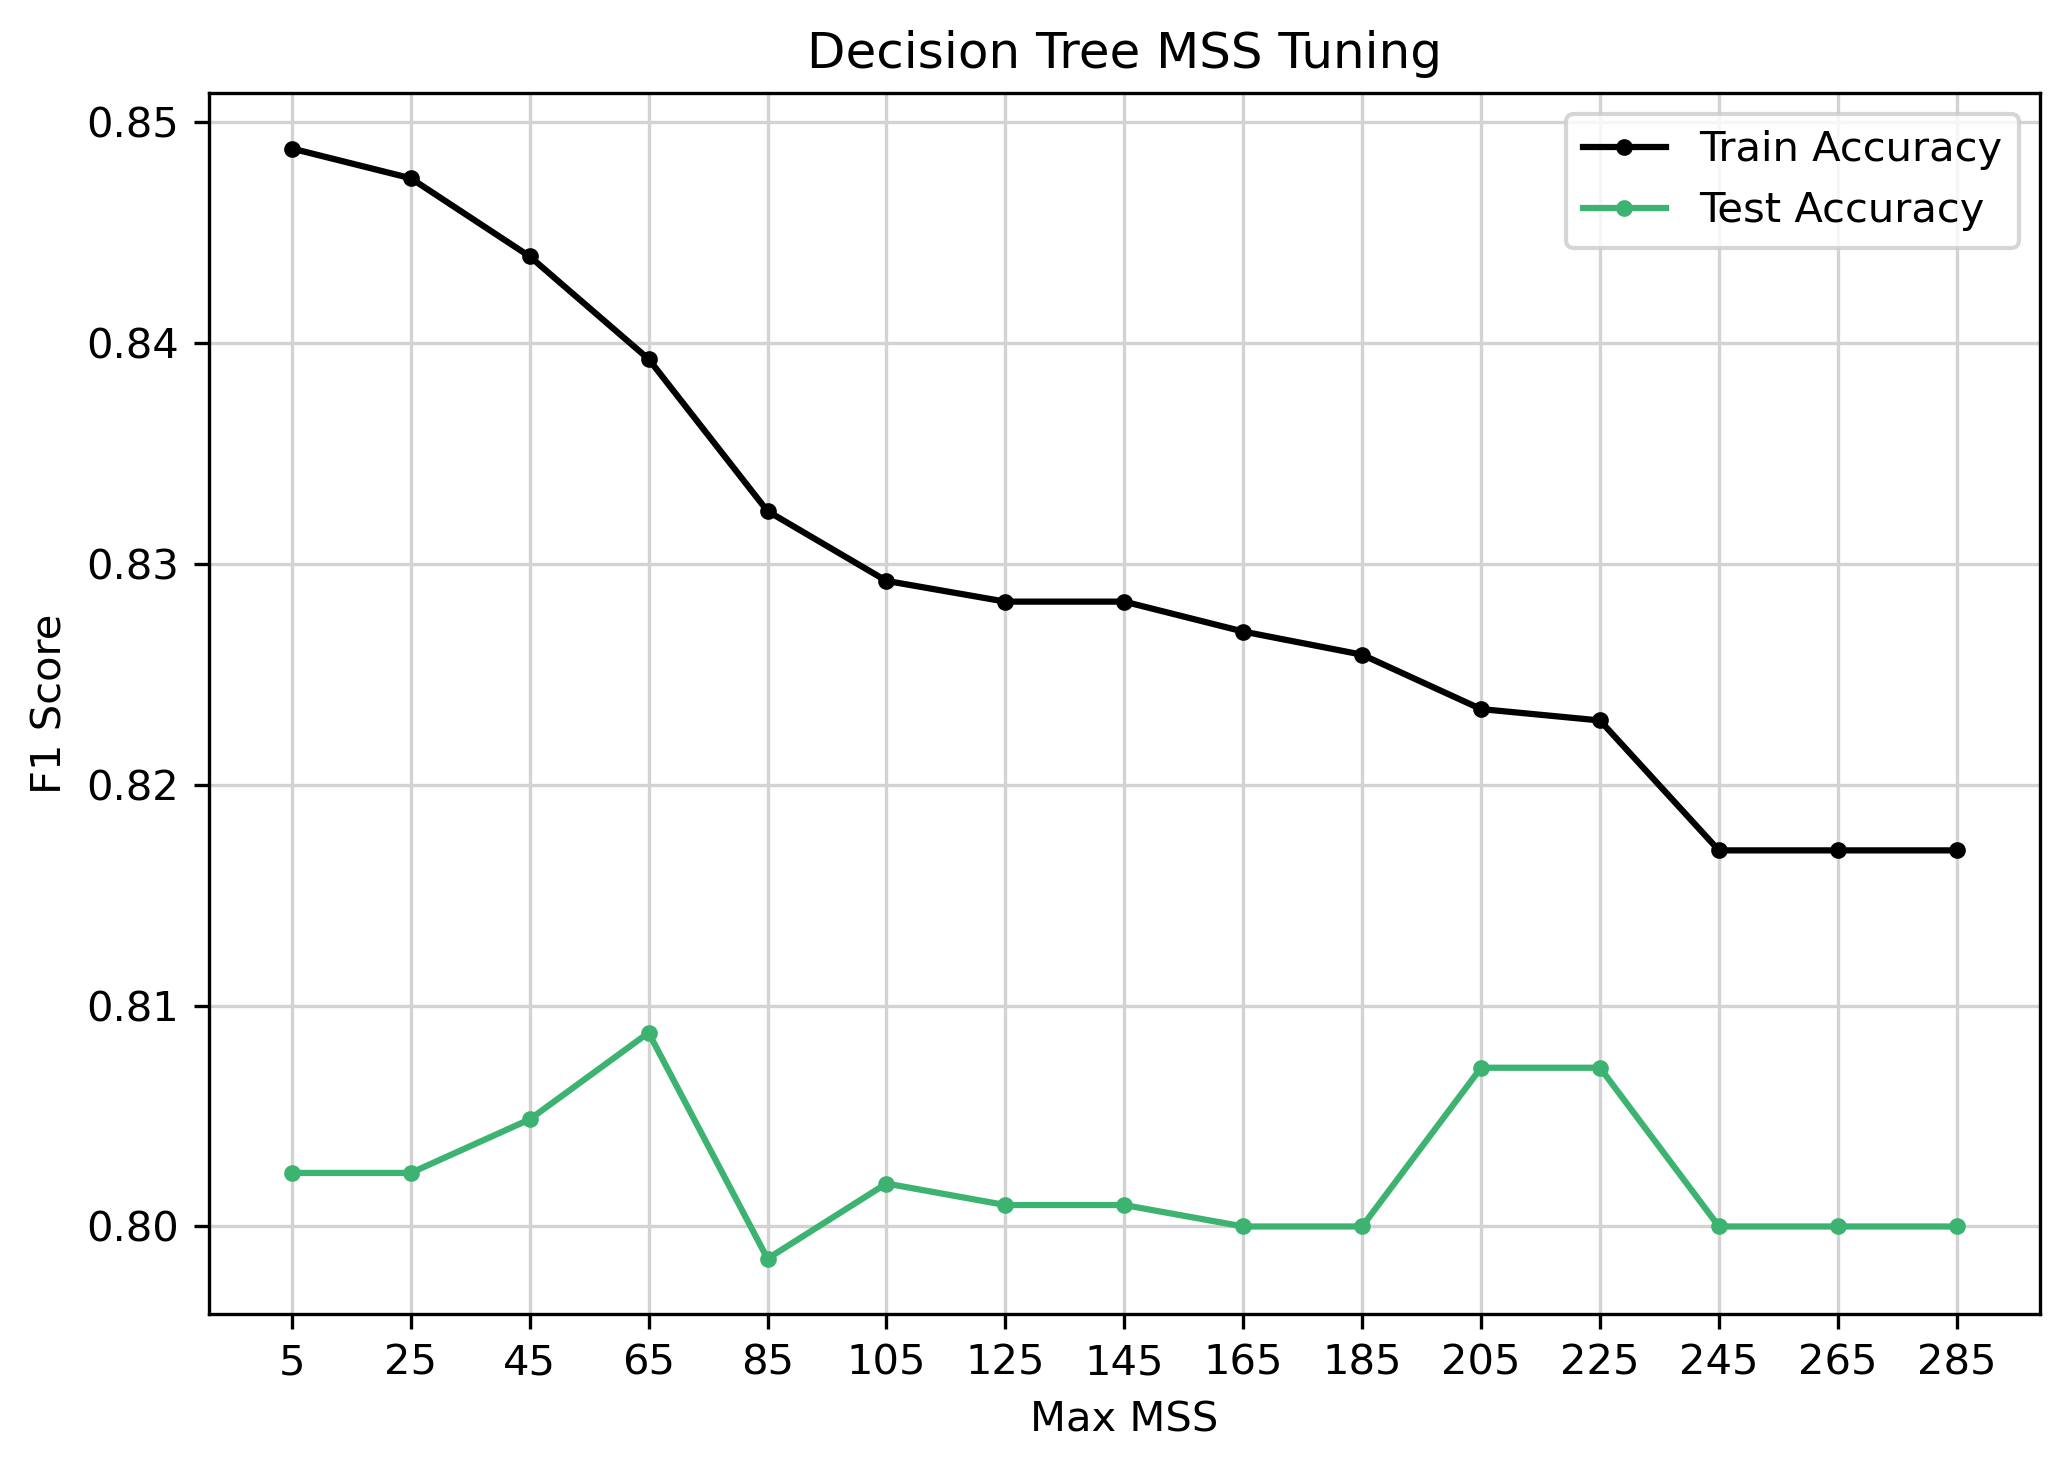

Best min_samples_split based on test f1-score: 65


In [8]:
from sklearn.metrics import f1_score

# 8. Hyperparameter tuning for min_samples_split (f1-score)
mss_range = range(5, 300, 20)
train_scores = []
test_scores = []

for mss in mss_range:
    model = DecisionTreeClassifier(random_state=RSEED, min_samples_split=mss, ccp_alpha=CCP_ALPHA)
    model.fit(train_X, train_y)
    
    train_pred = model.predict(train_X)
    test_pred = model.predict(test_X)
    
    train_scores.append(f1_score(train_y, train_pred))
    test_scores.append(f1_score(test_y, test_pred))

plt.figure(figsize=(7, 5))
plt.plot(mss_range, train_scores, label='Train Accuracy', marker='.', color='black')
plt.plot(mss_range, test_scores, label='Test Accuracy', marker='.', color='mediumseagreen')
plt.xlabel('Max MSS')
plt.ylabel('F1 Score')
plt.title('Decision Tree MSS Tuning')
plt.legend()
plt.grid(color='lightgray')
plt.xticks(mss_range)
plt.tight_layout()
plt.show()

# -- Best MSS (highest f1-score)
best_mss = mss_range[np.argmax(test_scores)]
print(f'Best min_samples_split based on test f1-score: {best_mss}')